In [244]:
###testing R in jyupter 
system("type R")

In [245]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [246]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

In [247]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "AKR_J.+featureCounts$", full.names = T)

f_files

[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts"
[2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts"
[3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts"
[4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts"
[5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts"
[6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts"
[7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts"
[8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts"
[9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts"

In [248]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "AKR_J-12.5dpp" "AKR_J-12.5dpp" "AKR_J-12.5dpp" "AKR_J-16.5dpc"
[5] "AKR_J-16.5dpc" "AKR_J-16.5dpc" "AKR_J-20.5dpp" "AKR_J-20.5dpp"
[9] "AKR_J-20.5dpp"

In [249]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))
lables

[1] "AKR_J-12.5dpp.1" "AKR_J-12.5dpp.2" "AKR_J-12.5dpp.3" "AKR_J-16.5dpc.1"
[5] "AKR_J-16.5dpc.2" "AKR_J-16.5dpc.3" "AKR_J-20.5dpp.1" "AKR_J-20.5dpp.2"
[9] "AKR_J-20.5dpp.3"

In [250]:
raw <- readDGE(f_files, columns = c(1, 7), comment.char = "#", sep="\t", group= samplenames, labels = lables,)

In [251]:
raw


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-12.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-12.5dpp,32170112,1
AKR_J-12.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-12.5dpp,32999174,1
AKR_J-12.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-12.5dpp,34885662,1
AKR_J-16.5dpc.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts,AKR_J-16.5dpc,30152143,1
AKR_J-16.5dpc.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts,AKR_J-16.5dpc,33725644,1
AKR_J-16.5dpc.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts,AKR_J-16.5dpc,34218390,1
AKR_J-20.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts,AKR_J-20.5dpp,34053358,1
AKR_J-20.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts,AKR_J-20.5dpp,33420664,1
AKR_J-20.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts,AKR_J-20.5dpp,29358964,1


In [252]:
z <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
geneName = na.omit(mcols(z)[,c("gene_id","parent_gene_display_xref")]) #get gene symbloes for respective gene id 

In [253]:
geneName

DataFrame with 51223 rows and 2 columns
                 gene_id parent_gene_display_xref
             <character>              <character>
1     ENSMUSG00220052967                  Gm37665
2     ENSMUSG00220035080            4933401J01Rik
3     ENSMUSG00220035079                  Gm26206
4     ENSMUSG00220035076                     Xkr4
5     ENSMUSG00220035074                  Gm18956
...                  ...                      ...
51219 ENSMUSG00220029990            4933400A11Rik
51220 ENSMUSG00220029994            G530011O06Rik
51221 ENSMUSG00220029995                  Gm15726
51222 ENSMUSG00220029992                  Gm15247
51223 ENSMUSG00220029996                    Erdr1

In [254]:
rownames(geneName) <- geneName$gene_id
geneName$gene_id <- NULL
geneName

DataFrame with 51223 rows and 1 column
                   parent_gene_display_xref
                                <character>
ENSMUSG00220052967                  Gm37665
ENSMUSG00220035080            4933401J01Rik
ENSMUSG00220035079                  Gm26206
ENSMUSG00220035076                     Xkr4
ENSMUSG00220035074                  Gm18956
...                                     ...
ENSMUSG00220029990            4933400A11Rik
ENSMUSG00220029994            G530011O06Rik
ENSMUSG00220029995                  Gm15726
ENSMUSG00220029992                  Gm15247
ENSMUSG00220029996                    Erdr1

In [255]:
library(dplyr)
raw$counts <- merge(x=raw$counts, y=geneName,by = 0,all.x=TRUE ) #left merge 
raw

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-12.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-12.5dpp,32170112,1
AKR_J-12.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-12.5dpp,32999174,1
AKR_J-12.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-12.5dpp,34885662,1
AKR_J-16.5dpc.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts,AKR_J-16.5dpc,30152143,1
AKR_J-16.5dpc.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts,AKR_J-16.5dpc,33725644,1
AKR_J-16.5dpc.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts,AKR_J-16.5dpc,34218390,1
AKR_J-20.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts,AKR_J-20.5dpp,34053358,1
AKR_J-20.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts,AKR_J-20.5dpp,33420664,1
AKR_J-20.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts,AKR_J-20.5dpp,29358964,1


In [256]:
raw$counts['Row.names'] <- NULL #remove the columns name Row.names


In [257]:
raw$counts <- raw$counts[!is.na(raw$counts$parent_gene_display_xref),] #remove NA 
raw$counts

,AKR_J-12.5dpp.1,AKR_J-12.5dpp.2,AKR_J-12.5dpp.3,AKR_J-16.5dpc.1,AKR_J-16.5dpc.2,AKR_J-16.5dpc.3,AKR_J-20.5dpp.1,AKR_J-20.5dpp.2,AKR_J-20.5dpp.3,parent_gene_display_xref
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
4,236.00,204.17,261.00,687.33,739.00,781.33,114.00,128.00,81.00,Aif1l
5,689.61,670.02,722.53,332.67,311.58,406.14,1678.88,1533.43,1260.06,Fam78a
6,3242.25,3373.38,3730.25,2929.55,3302.83,3435.43,3786.70,3325.83,2895.84,Nup214
7,835.58,933.05,895.80,1072.15,1327.19,1140.00,568.00,597.06,467.00,Mcm10
8,1845.52,1924.04,2060.08,897.65,857.57,999.42,4898.02,4483.38,4215.84,Optn
9,200.00,202.19,202.44,260.43,196.00,245.52,91.40,111.33,82.47,Ccdc3
10,8.56,6.12,12.47,36.03,22.55,27.10,8.50,1.57,6.03,Ucma
11,1523.25,1389.50,1860.28,626.54,743.50,921.67,813.62,764.50,579.50,Pfkfb3
12,1.00,0.00,2.00,1.00,1.00,1.00,0.00,0.00,0.00,4933403L11Rik


In [258]:

raw$counts <- raw$counts %>% group_by(parent_gene_display_xref) %>% summarise(across(everything(), sum))

In [259]:


raw$counts <- as.data.frame(raw$counts[!duplicated(raw$counts$parent_gene_display_xref), ])  #remove dulicate values 

rownames(raw$counts) <- raw$counts$parent_gene_display_xref #set rawname to gene symbloes 
raw$counts$parent_gene_display_xref <- NULL #remove genesybloe columns 



In [260]:
raw

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-12.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.1.featureCounts,AKR_J-12.5dpp,32170112,1
AKR_J-12.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.2.featureCounts,AKR_J-12.5dpp,32999174,1
AKR_J-12.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-12.5dpp.3.featureCounts,AKR_J-12.5dpp,34885662,1
AKR_J-16.5dpc.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts,AKR_J-16.5dpc,30152143,1
AKR_J-16.5dpc.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts,AKR_J-16.5dpc,33725644,1
AKR_J-16.5dpc.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts,AKR_J-16.5dpc,34218390,1
AKR_J-20.5dpp.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.1.featureCounts,AKR_J-20.5dpp,34053358,1
AKR_J-20.5dpp.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.2.featureCounts,AKR_J-20.5dpp,33420664,1
AKR_J-20.5dpp.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-20.5dpp.3.featureCounts,AKR_J-20.5dpp,29358964,1


In [261]:
#DESeq and PCA and Dandogram 

#conda install -c bioconda bioconductor-deseq2 r-gplots r-rcolorbrewer r-ggplot2 r-tidyr r-ggrepel r-dplyr -y 
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

In [262]:

#save results in this folder 
#mkdir -p  /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/AKR_J
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/AKR_J")

In [263]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"

In [264]:
# Now we build a DESeq2 Count dataset and normalize it.
mircounts <- raw$counts

cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates: 124 workers

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not 

In [265]:
#rlog normalisations
rl=vst(cds)
pdf("AKR_J_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames)
postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames)
dev.off()

png 
  2

In [266]:
####
# Margins area


pdf("AKR_J_InitialHeatMap.pdf",paper="special",title="Trinity Assemblies",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()

ERROR: Error in plot.new(): figure margins too large


In [ ]:
##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="AKR_J_dendrogram.pdf")
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

[1] "AKR_J-12.5dpp.1" "AKR_J-12.5dpp.2" "AKR_J-12.5dpp.3" "AKR_J-16.5dpc.1"
[5] "AKR_J-16.5dpc.2" "AKR_J-16.5dpc.3" "AKR_J-20.5dpp.1" "AKR_J-20.5dpp.2"
[9] "AKR_J-20.5dpp.3"

,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp
,<dbl>,<dbl>,<dbl>
Aif1l,225.8361,671.7388,127.8076
Fam78a,671.5572,319.5590,1776.6620
Nup214,3332.8837,2940.8485,3980.6280
Mcm10,859.2706,1078.0400,649.2801
Optn,1878.7990,839.0262,5426.9960
Ccdc3,194.8081,214.5299,113.1157


[1] 24485

[1] 3959

,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp
,<dbl>,<dbl>,<dbl>
Nmt2,14371.2994,5700.239,7101.873
Tubb4b,8665.8205,7482.907,25892.691
Fam107b,963.2437,1221.785,8044.570
Ralgds,1725.8016,2607.535,9002.511
Meig1,1064.3734,103.438,35154.312
Setx,38732.8103,13201.958,134897.844


,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<chr>
Nmt2,14371.2994,5700.239,7101.873,Nmt2
Tubb4b,8665.8205,7482.907,25892.691,Tubb4b
Fam107b,963.2437,1221.785,8044.570,Fam107b
Ralgds,1725.8016,2607.535,9002.511,Ralgds
Meig1,1064.3734,103.438,35154.312,Meig1
Setx,38732.8103,13201.958,134897.844,Setx


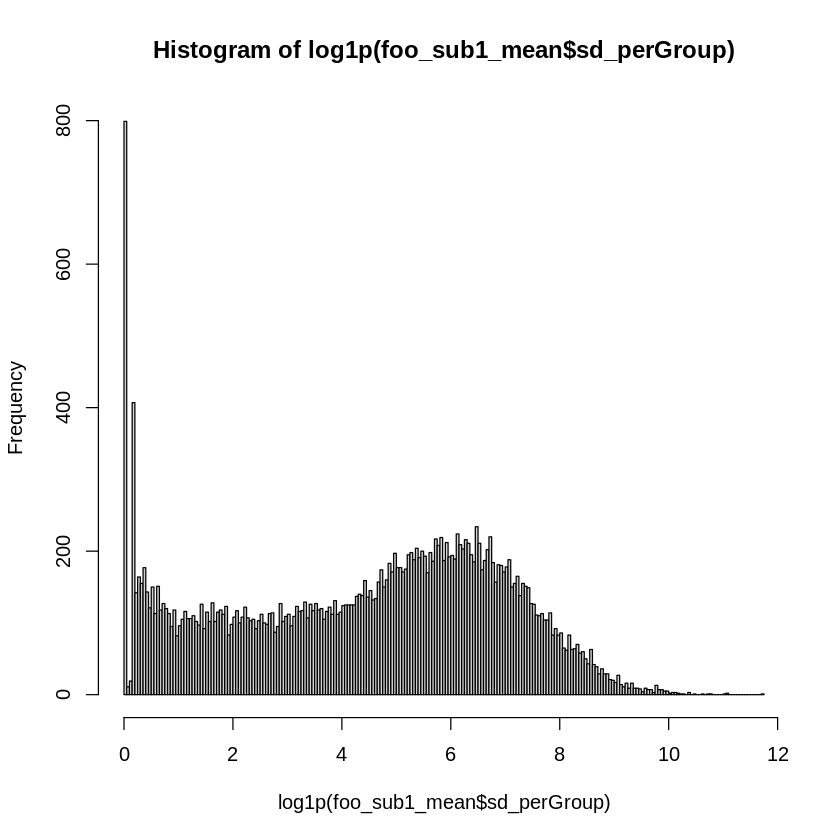

Warning message:
“‘mode(width)’ differs between new and previous
	 ==> NOT changing ‘width’”


png 
  2

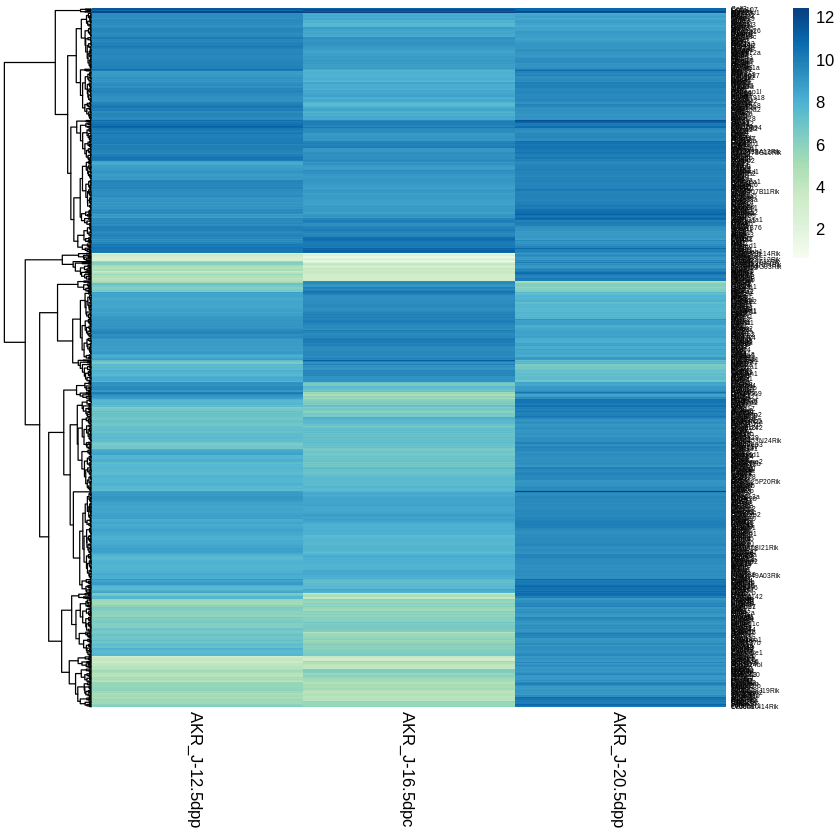

In [ ]:
#conda install -c bioconda r-pheatmap -y 
##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

#head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:3]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename,  height=100) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:3]), border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(savePheatmap,"AKR_J_InitialPheatMap.pdf")

Warning message:
“‘mode(width)’ differs between new and previous
	 ==> NOT changing ‘width’”


png 
  2

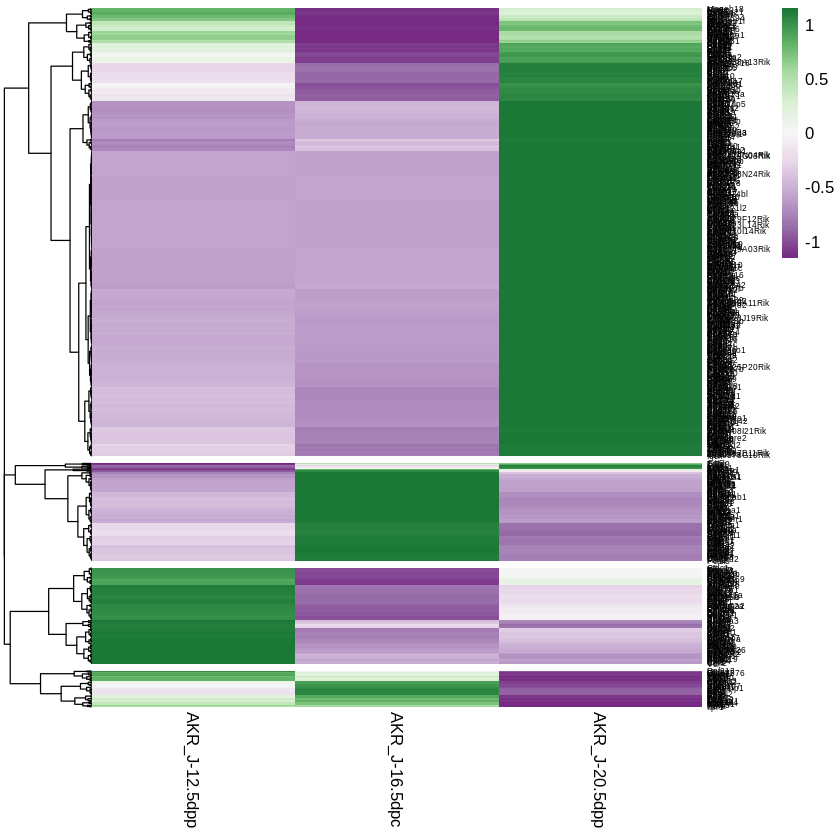

In [ ]:

##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:3], border_color = NA,show_rownames = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 4,fontsize_row = 5, cluster_cols = F, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"AKR_J_InitialPheatMap_zScore.pdf")